**Predikcija snage poker ruke na Riveru**

Cilj ovog dela projekta je da se predvidi jačina poker ruke na Riveru na osnovu informacija dostupnih na **flopu i turnu**, i da se izvrši detaljna analiza podataka iz datog skupa podataka.

Izgradićemo osnovni model klasifikacije i proceniti koliko je problem težak.

In [13]:
import sys
from pathlib import Path

# Dodajemo src folder u Python path
PROJECT_ROOT = Path().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"
sys.path.append(str(SRC_PATH))

import pandas as pd
from poker_eda import load_data, basic_info

df = load_data("../data/poker_dataset.csv")
basic_info(df)

df.head()

Shape: (1000000, 7)

Columns: ['hand', 'flop', 'result1', 'turn', 'result2', 'river', 'result3']


,hand,flop,result1,turn,result2,river,result3
0,♣K ♥6,♦Q ♣3 ♥3,PAIR,♦Q ♣3 ♥3 ♣7,PAIR,♦Q ♣3 ♥3 ♣7 ♣6,TWO PAIR
1,♦4 ♦3,♥5 ♣2 ♥6,STRAIGHT,♥5 ♣2 ♥6 ♥A,STRAIGHT,♥5 ♣2 ♥6 ♥A ♠Q,STRAIGHT
2,♥7 ♣5,♥A ♣6 ♥5,PAIR,♥A ♣6 ♥5 ♣7,TWO PAIR,♥A ♣6 ♥5 ♣7 ♣4,TWO PAIR
3,♠2 ♣J,♥10 ♠A ♠9,NOTHING,♥10 ♠A ♠9 ♦4,NOTHING,♥10 ♠A ♠9 ♦4 ♦3,NOTHING
4,♠K ♥9,♥Q ♦K ♦A,PAIR,♥Q ♦K ♦A ♣8,PAIR,♥Q ♦K ♦A ♣8 ♦4,PAIR


Dataset sadrži 1.000.000 instanci i 7 kolona koje opisuju razvoj poker ruke kroz tri faze igre (flop, turn i river).
Podaci su kompletni i spremni za dalju eksplorativnu analizu.


Distribution for result1:
                  Count  Percentage
result1                            
NOTHING          501205       50.12
PAIR             422882       42.29
TWO PAIR          47453        4.75
THREE OF A KIND   21305        2.13
STRAIGHT           3511        0.35
FLUSH              1952        0.20
FULL HOUSE         1425        0.14
FOUR OF A KIND      255        0.03
STRAIGHT FLUSH       10        0.00
ROYAL FLUSH           2        0.00


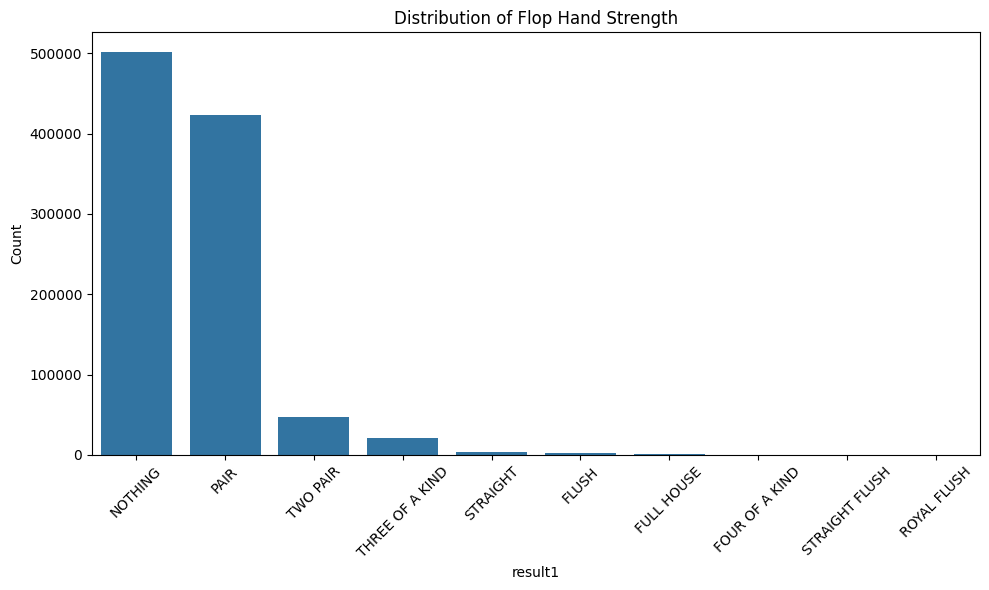


Distribution for result2:
                  Count  Percentage
result2                            
PAIR             478473       47.85
NOTHING          329333       32.93
TWO PAIR         121124       12.11
THREE OF A KIND   36231        3.62
STRAIGHT          15993        1.60
FLUSH              9808        0.98
FULL HOUSE         8231        0.82
FOUR OF A KIND      730        0.07
STRAIGHT FLUSH       65        0.01
ROYAL FLUSH          12        0.00


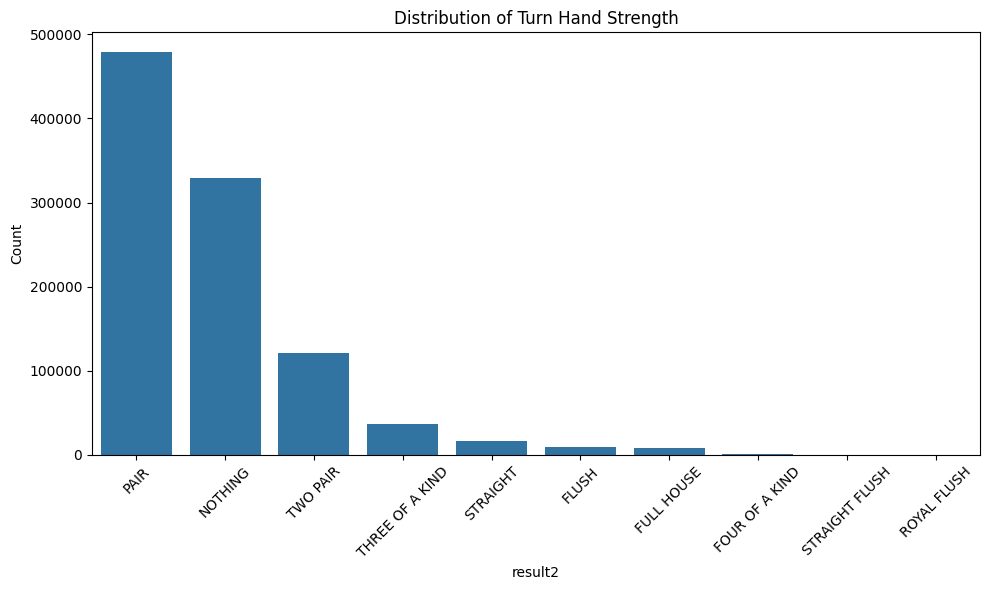


Distribution for result3:
                  Count  Percentage
result3                            
PAIR             440508       44.05
TWO PAIR         216731       21.67
NOTHING          196091       19.61
THREE OF A KIND   48901        4.89
STRAIGHT          41722        4.17
FLUSH             28437        2.84
FULL HOUSE        25612        2.56
FOUR OF A KIND     1697        0.17
STRAIGHT FLUSH      263        0.03
ROYAL FLUSH          38        0.00


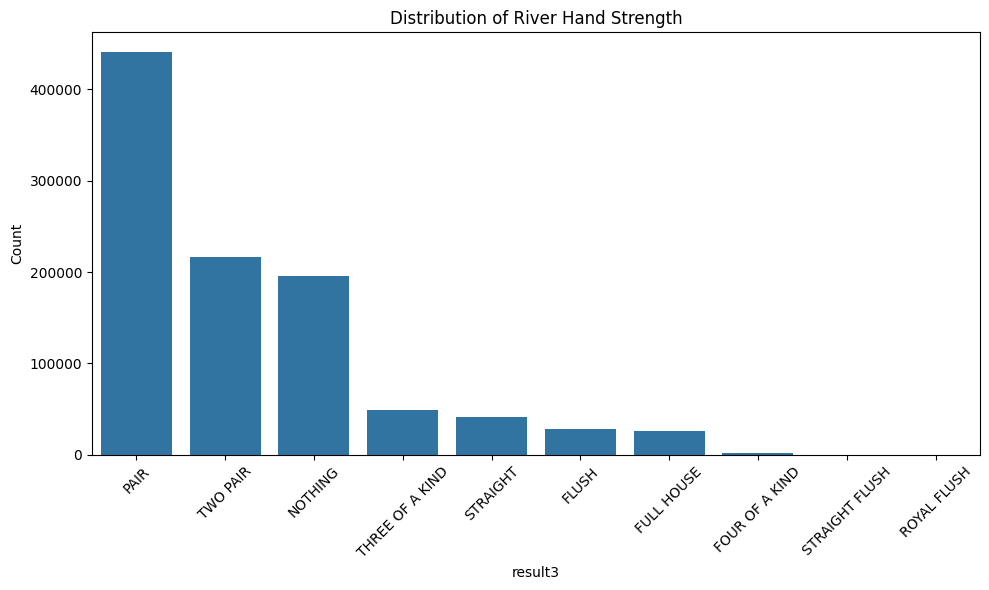

In [14]:
from poker_eda import plot_distribution

plot_distribution(df, "result1")
plot_distribution(df, "result2")
plot_distribution(df, "result3")

Vidimo da na flopu dominiraju slabije kombinacije (Nothing i Pair), što je i očekivano jer je manji broj karata na stolu. 

Kako prelazimo na Turn i River, primećujemo smanjenje udela Nothing, i rast ostalih udela poput Two Pair, Straight i jačih ruku.

Udeo pojava veoma jakih ruku poput Straight Flush i Royal Flush je očekivano veoma mali u svim fazama igre.

**Preprocesiranje**

U Texas Hold'em pokeru, snaga ruke ne može da se pogorša pri otkrivanju novih karata (flush ne može postati pair, pair ne može postati nothing...)

Zato proveravamo da li postoje instance gde je:
- Turn slabiji od Flopa
- River slabiji od Turna
- River slabiji od Flopa

Takve redove smatramo netačnim i uklanjamo ih iz skupa podataka

In [15]:
from poker_eda import hand_rank

# Mapiranje kategorija u numeričke rangove
df["rank1"] = df["result1"].map(hand_rank)
df["rank2"] = df["result2"].map(hand_rank)
df["rank3"] = df["result3"].map(hand_rank)

# Broj nekonzistentnih slučajeva
worse_flop_turn = (df["rank2"] < df["rank1"]).sum()
worse_turn_river = (df["rank3"] < df["rank2"]).sum()
worse_flop_river = (df["rank3"] < df["rank1"]).sum()

print("Turn slabiji od flopa:", worse_flop_turn)
print("River slabiji od turna:", worse_turn_river)
print("River slabiji od flopa:", worse_flop_river)

# Uklanjanje nekonzistentnih redova
df_clean = df[
    (df["rank2"] >= df["rank1"]) &
    (df["rank3"] >= df["rank2"]) &
    (df["rank3"] >= df["rank1"])
]

print("Broj instanci nakon čišćenja:", df_clean.shape[0])

Turn slabiji od flopa: 3476
River slabiji od turna: 17799
River slabiji od flopa: 19205
Broj instanci nakon čišćenja: 978725


**Razdvajanje kategorije PAIR**

Kategorija *PAIR* je veoma česta, ali nije svaki par isti po jačini. Na primer, par dvojki je mnogo slabiji od para asova.

Zbog toga kategoriju *PAIR* delimo na:
- LOW_PAIR - parovi od 2 do 9
- HIGH_PAIR - parovi od 10 do A

Ova podela će nam pomoći pri kasnijoj klasifikaciji završne jačine ruke.

In [16]:
from poker_eda import classify_pair

# Kreiranje novih klasifikovanih kolona
for col in ["result1", "result2", "result3"]:
    df_clean[f"{col}_class"] = df_clean.apply(
        lambda row: classify_pair(row, col),
        axis=1
    )

df_clean[["result1", "result1_class"]].head()

,result1,result1_class
0,PAIR,HIGH_PAIR
1,STRAIGHT,STRAIGHT
2,PAIR,LOW_PAIR
3,NOTHING,NOTHING
4,PAIR,HIGH_PAIR



Distribution for result1_class:
                  Count  Percentage
result1_class                      
NOTHING          500279       51.12
HIGH_PAIR        254149       25.97
LOW_PAIR         157722       16.12
TWO PAIR          38964        3.98
THREE OF A KIND   21186        2.16
STRAIGHT           3511        0.36
FLUSH              1339        0.14
FULL HOUSE         1308        0.13
FOUR OF A KIND      255        0.03
STRAIGHT FLUSH       10        0.00
ROYAL FLUSH           2        0.00


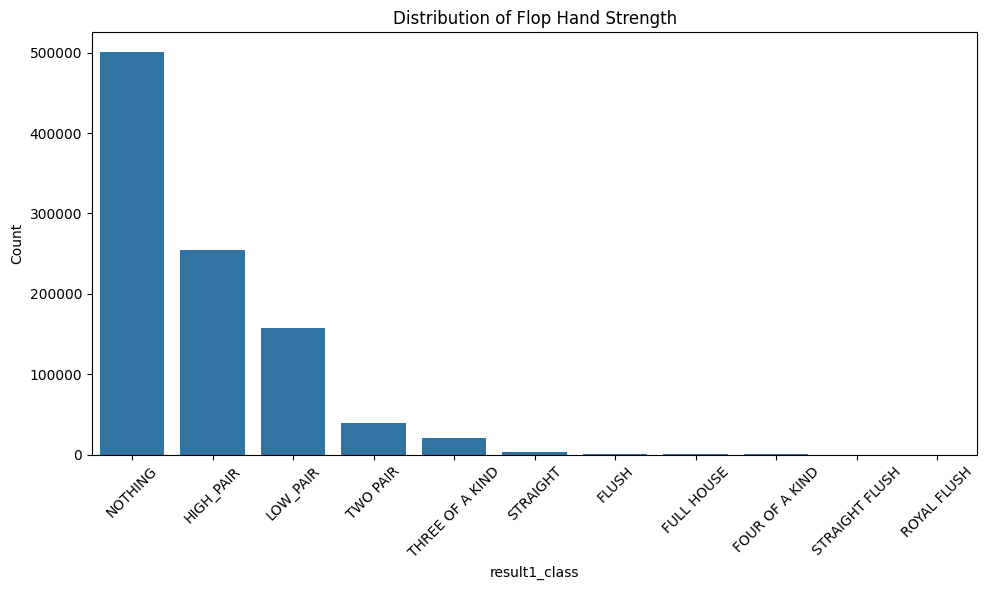


Distribution for result2_class:
                  Count  Percentage
result2_class                      
NOTHING          325920       33.30
HIGH_PAIR        300015       30.65
LOW_PAIR         178458       18.23
TWO PAIR         105324       10.76
THREE OF A KIND   36168        3.70
STRAIGHT          15993        1.63
FLUSH              8171        0.83
FULL HOUSE         7869        0.80
FOUR OF A KIND      730        0.07
STRAIGHT FLUSH       65        0.01
ROYAL FLUSH          12        0.00


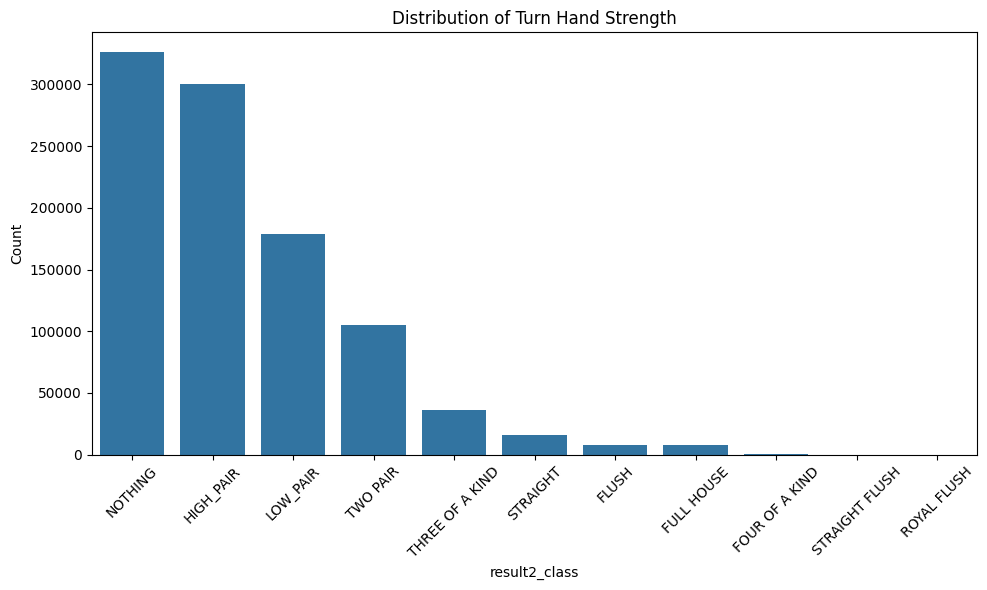


Distribution for result3_class:
                  Count  Percentage
result3_class                      
HIGH_PAIR        278522       28.46
TWO PAIR         216731       22.14
NOTHING          176612       18.05
LOW_PAIR         161107       16.46
THREE OF A KIND   48479        4.95
STRAIGHT          41640        4.25
FLUSH             28437        2.91
FULL HOUSE        25208        2.58
FOUR OF A KIND     1694        0.17
STRAIGHT FLUSH      258        0.03
ROYAL FLUSH          37        0.00


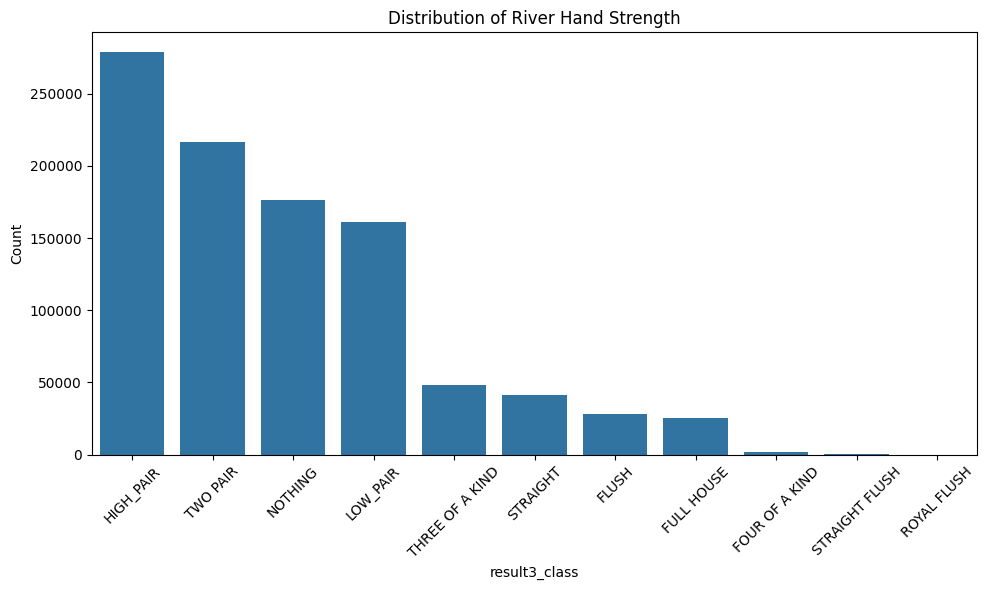

In [17]:
from poker_eda import plot_distribution

plot_distribution(df_clean, "result1_class")
plot_distribution(df_clean, "result2_class")
plot_distribution(df_clean, "result3_class")

Na osnovu prethodnih grafika i poker hijerarhije, formiramo 3 nivoa jačine ruku:
- Weak - NOTHING, LOW_PAIR
- Strong - HIGH_PAIR, TWO PAIR, THREE OF A KIND
- Premium - sve ostale jačine

                 Count  Percentage
river_strength                    
Strong          543732       55.56
Weak            337719       34.51
Premium          97274        9.94


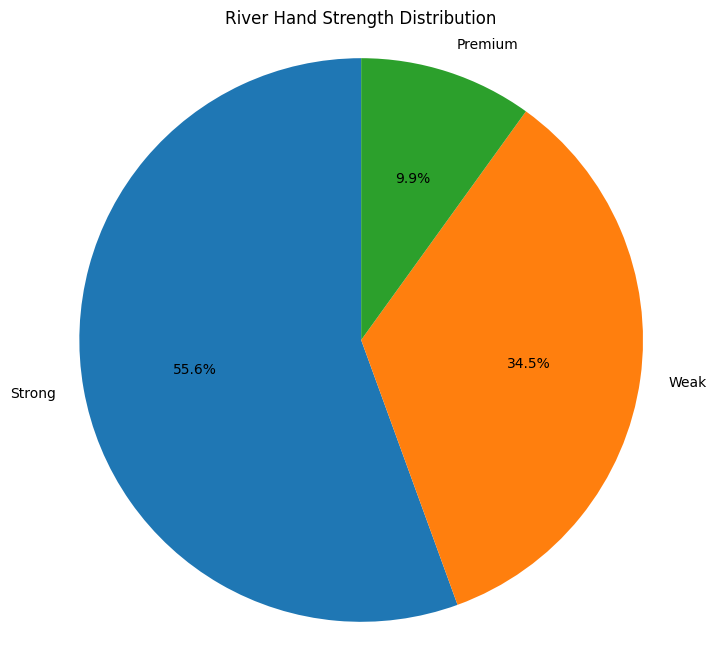

In [18]:
from poker_eda import strength_category
import matplotlib.pyplot as plt

df_clean["river_strength"] = df_clean["result3_class"].apply(strength_category)
strength_counts = df_clean["river_strength"].value_counts()
strength_percent = df_clean["river_strength"].value_counts(normalize=True) * 100

print(pd.DataFrame({
        "Count": strength_counts,
        "Percentage": strength_percent.round(2)
    }))

plt.figure(figsize=(8,8))
plt.pie(
    strength_counts,
    labels=strength_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("River Hand Strength Distribution")
plt.axis("equal")
plt.show()

Odnos snaga ruku je očekivan

**Matrica tranzicije Flop -> River**
- Redovi: Flop ruke
- Kolone: River ruke
- Vrednosti: procentualna verovatnoća da ruka iz Flopa završi kao neka ruka na Riveru

Ova matrica nam vizuelno pokazuje koje ruke imaju najveću šansu da se poboljšaju.

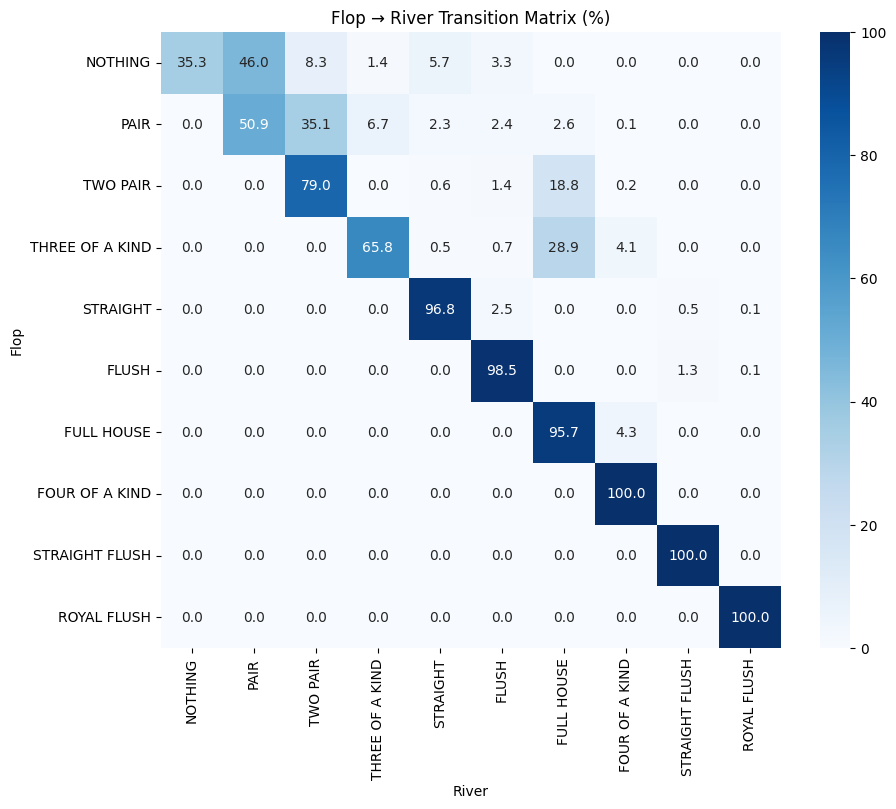

In [19]:
from poker_eda import sns

# PRIKAZIVANJE MATRICE TRANZICIJE FLOP → RIVER
# Mapiranje rank nazad u string
rank_to_hand = {v: k for k, v in hand_rank.items()}

    # Kreiranje transition matrice sa rankovima
transition_matrix_pct = pd.crosstab(
    df_clean["rank1"],  # result1
    df_clean["rank3"],  # result3
    normalize="index"
) * 100

    # Zamena redova i kolona stringovima
transition_matrix_pct.index = transition_matrix_pct.index.map(rank_to_hand)
transition_matrix_pct.columns = transition_matrix_pct.columns.map(rank_to_hand)

    # Prikaz heatmap-a
plt.figure(figsize=(10,8))
sns.heatmap(transition_matrix_pct.round(1), annot=True, fmt=".1f", cmap="Blues")
plt.title("Flop → River Transition Matrix (%)")
plt.ylabel("Flop")
plt.xlabel("River")
plt.show()

Sve vrednosti ispod glavne dijagonale su očekivano nula, jer smo takve slučajeve uklonili tokom preprocesiranja. Većina ruku ostaje iste jačine (pogotovo kod jakih ruku na flopu), ali vidimo i ostale slučajeve u kojima jačine ruku napreduju. Najčešći takvi slučajevi su:
- PAIR -> TWO PAIR
- NOTHING -> PAIR
- THREE OF A KIND -> FULL HOUSE
- TWO PAIR -> FULL HOUSE

Ove slučajeve iskusni poker igrači imaju u vidu kad planiraju da vrše blefiranje, i zbog toga nam je ova matrica veoma bitna.

Na kraju vršimo klasifikaciju River ruke koristeći Random Forest

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Target
y = df_clean["river_strength"]  # Weak / Strong / Premium

# Feature-e: one-hot encoding za Flop i Turn klasifikovane ruke
X = pd.get_dummies(df_clean[["result1_class", "result2_class"]])

# Podela na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predikcija
y_pred = model.predict(X_test)

# Evaluacija
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7961071802600321

Classification Report:
               precision    recall  f1-score   support

     Premium       1.00      0.33      0.50     19362
      Strong       0.93      0.75      0.83    108628
        Weak       0.67      1.00      0.80     67755

    accuracy                           0.80    195745
   macro avg       0.87      0.70      0.71    195745
weighted avg       0.84      0.80      0.79    195745



Ukupna tačnost od oko 80% pokazuje solidnu sposobnost modela da predvidi Rver ruke na osnovu Flopa i Turna.

Model je naročito precizan u detekciji Strong i Weak kategorija, dok bi Premium kategorija zahtevala dodatne pristupe poput balansiranja klasa ili korišćenje težinskih parametara u Random Forest-u kako bi se poboljšao Recall.